# Clasificación de Sectores de Patentes con TF-IDF + Regresión Logística

**Objetivo:** Entrenar un clasificador sobre `ipc_sector.csv` y aplicarlo al nuevo dataset `combined_dataset.csv`.

**Variable objetivo:** `Sector` (5 clases: Química, Ingeniería mecánica, Instrumentos, Otros sectores, Electricidad - Electrónica)  
**Features:** Códigos IPC de la columna `Clasificacion` / `IPC` (texto estructurado)


## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight


## 2. Carga y exploración de datos

In [3]:
df = pd.read_csv("C:/Users/david/OneDrive/Documents/Universidad/archivos semillero/ipc_sector.csv")
print("Shape:", df.shape)
print()
df[["Clasificacion", "Sector","Titulo"]].head(8)


Shape: (77377, 4)



,Clasificacion,Sector,Titulo
0,A61B 17/58,Instrumentos,UN DISPOSITIVO DE FIJACION QUIRURGICO
1,E06C 1/38; E06C 5/02,Otros sectores,DISPOSITIVO DE ACCESO
2,A61F 13/15,Instrumentos,ARTICULO ABSORBENTE QUE TIENE BANDA DE DISTRIB...
3,B07B 1/46; B07B 13/00,Química,TAMIZ VIBRATORIO DE POLIURETANO
4,A23C 9/142,Química,COMPOSICION LACTEA Y PROCEDIMIENTO DE PREPARACION
5,C09K 17/00,Química,COMPOSICION Y METODO PARA DESHALOGENACION Y DE...
6,C03B 33/00; A44C 17/00,Otros sectores,TRATAMIENTO PARA PIEDRAS PRECIOSAS
7,A61K 31/19,Química,DERIVADOS DE ACIDO CARBOXILICO AROMATICO


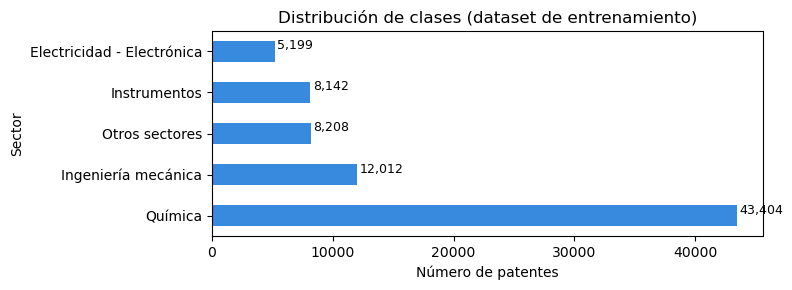

Sector
Química                       43404
Ingeniería mecánica           12012
Otros sectores                 8208
Instrumentos                   8142
Electricidad - Electrónica     5199
Name: count, dtype: int64


In [4]:
# Distribución de clases
ax = df["Sector"].value_counts().plot(kind="barh", figsize=(8, 3), color="#378ADD")
ax.set_title("Distribución de clases (dataset de entrenamiento)")
ax.set_xlabel("Número de patentes")
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width() + 200, p.get_y() + 0.3), fontsize=9)
plt.tight_layout()
plt.show()
print(df["Sector"].value_counts())


## 3. Preprocesamiento

Se normalizan los separadores para que TF-IDF trate cada código IPC como token independiente.  
Ejemplo: `A61K 31/19; C07D 417/04` → `A61K 31 19 C07D 417 04`


In [5]:
def limpiar_ipc(texto):
    """Normaliza separadores para que cada código IPC sea un token."""
    if pd.isna(texto):
        return ""
    return texto.replace(";", " ").replace("/", " ").strip()

df["texto"] = df["Clasificacion"].apply(limpiar_ipc)

# Verificar
print("Ejemplo original: ", df["Clasificacion"].iloc[1])
print("Ejemplo procesado:", df["texto"].iloc[1])
print()
print(f"Registros sin IPC: {(df['texto'] == '').sum()}")


Ejemplo original:  E06C 1/38; E06C 5/02
Ejemplo procesado: E06C 1 38  E06C 5 02

Registros sin IPC: 7


## 4. División train / test (80 / 20)

In [6]:
df = df.dropna()
X = df["texto"]
y = df["Sector"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} registros")
print(f"Test:  {len(X_test):,} registros")
print()
print("Distribución train:")
print(y_train.value_counts())


Train: 61,568 registros
Test:  15,392 registros

Distribución train:
Sector
Química                       34723
Ingeniería mecánica            9608
Otros sectores                 6566
Instrumentos                   6514
Electricidad - Electrónica     4157
Name: count, dtype: int64


## 5. Pipeline: TF-IDF + Regresión Logística

**¿Por qué este modelo?**
- `Clasificacion` es texto estructurado con vocabulario finito (~25k tokens IPC únicos)
- TF-IDF captura la relevancia relativa de cada código por clase
- Regresión Logística multiclase es interpretable y muy eficiente en matrices sparse
- `class_weight='balanced'` corrige el desbalance (Química 58% vs Electricidad 7%)


In [7]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),   # unigramas y bigramas de códigos IPC
        min_df=2,             # ignorar códigos que aparecen menos de 2 veces
        sublinear_tf=True,    # aplica log(tf+1) para reducir el efecto de frecuencias altas
    )),
    ("clf", LogisticRegression(
        multi_class="ovr",        # one-vs-rest para 5 clases
        class_weight="balanced",  # corrige desbalance
        max_iter=1000,
        random_state=42,
        C=1.0,                    # regularización por defecto
        solver="lbfgs",
    ))
])

pipeline.fit(X_train, y_train)
print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.


## 6. Evaluación en conjunto de test

In [8]:
y_pred = pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred))


Accuracy: 0.9581

                            precision    recall  f1-score   support

Electricidad - Electrónica       0.92      0.96      0.94      1039
       Ingeniería mecánica       0.90      0.93      0.92      2402
              Instrumentos       0.93      0.95      0.94      1628
            Otros sectores       0.94      0.94      0.94      1642
                   Química       0.99      0.97      0.98      8681

                  accuracy                           0.96     15392
                 macro avg       0.94      0.95      0.94     15392
              weighted avg       0.96      0.96      0.96     15392



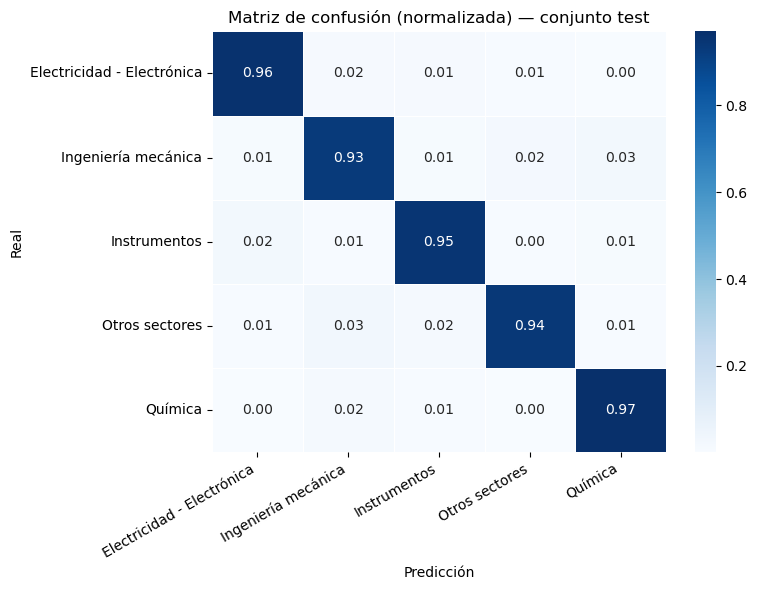

In [9]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=pipeline.classes_,
            yticklabels=pipeline.classes_,
            ax=ax, linewidths=0.5)
ax.set_title("Matriz de confusión (normalizada) — conjunto test")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 7. Validación cruzada (5-fold)

In [10]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print(f"Accuracy CV 5-fold:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Por fold: {[round(s, 4) for s in cv_scores]}")


Accuracy CV 5-fold:  0.9564 ± 0.0238
Por fold: [np.float64(0.9758), np.float64(0.9471), np.float64(0.9814), np.float64(0.9628), np.float64(0.915)]


## 8. Códigos IPC más importantes por sector

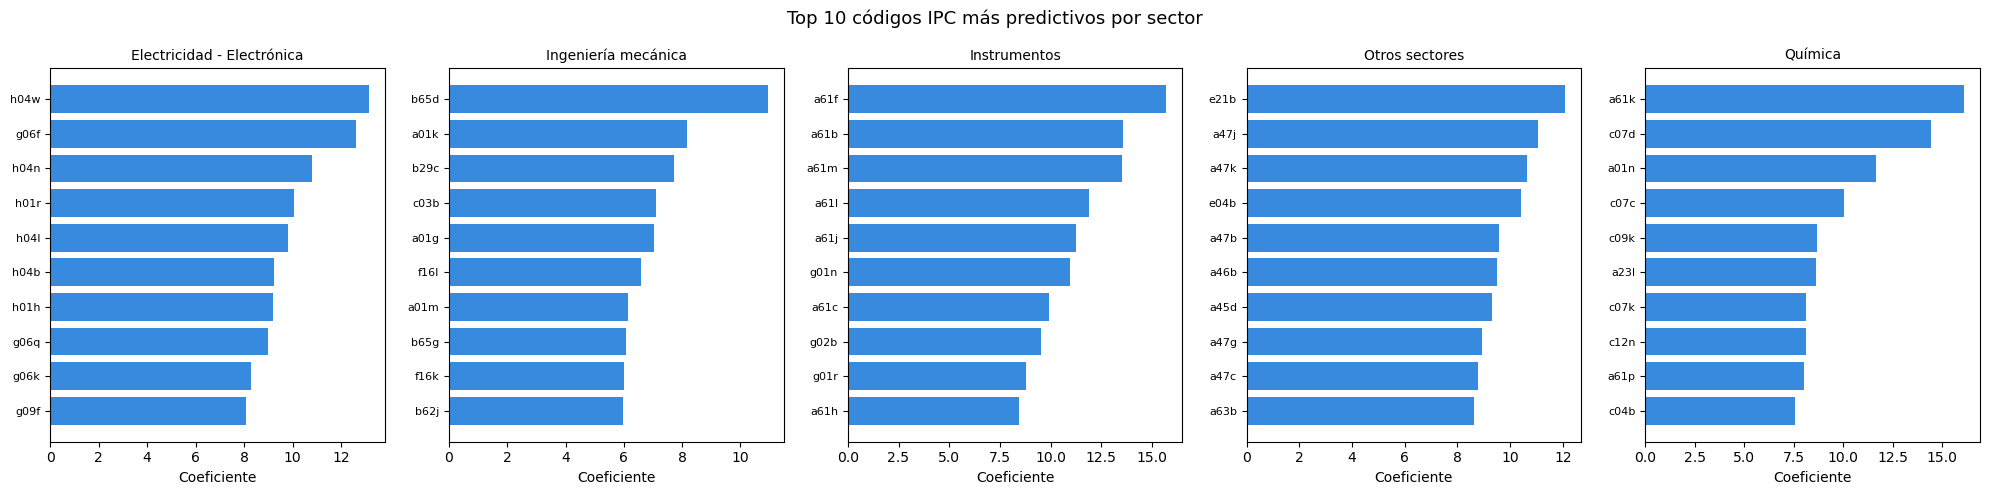

In [11]:
feature_names = pipeline.named_steps["tfidf"].get_feature_names_out()
coef = pipeline.named_steps["clf"].coef_
classes = pipeline.classes_

fig, axes = plt.subplots(1, len(classes), figsize=(20, 5), sharey=False)
fig.suptitle("Top 10 códigos IPC más predictivos por sector", fontsize=13, fontweight="500")

for i, (cls, ax) in enumerate(zip(classes, axes)):
    top_idx = np.argsort(coef[i])[-10:][::-1]
    top_features = feature_names[top_idx]
    top_coefs = coef[i][top_idx]
    ax.barh(top_features[::-1], top_coefs[::-1], color="#378ADD")
    ax.set_title(cls, fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel("Coeficiente")

plt.tight_layout()
plt.show()


In [12]:
import joblib
from joblib                             import dump, load

In [13]:
joblib.dump(pipeline, 'modelo_clf_patentes.pkl')

['modelo_clf_patentes.pkl']

## 9. Aplicar el modelo al nuevo dataset (`combined_dataset.csv`)

### Compatibilidad con el modelo

| Aspecto | Resultado |
|---|---|
| Formato IPC | Idéntico (`A61K 31/19; C07D 417/04`) |
| Overlap de códigos únicos | **96.7%** del nuevo dataset está visto en entrenamiento |
| Códigos no vistos | 614 de 18 802 (3.3%) — manejados por TF-IDF con peso 0 |
| Registros con IPC nulo | 3 189 (8.2%) — se excluyen automáticamente |

✅ **El modelo es directamente aplicable.** Solo se necesita usar la columna `IPC` en lugar de `Clasificacion`.


In [15]:
df_new = pd.read_excel("C:/Users/david/Downloads/Patentes_OMPI/merged_patents.xlsx")
print("Shape:", df_new.shape)
print("Columnas:", df_new.columns.tolist())
print()
print(f"Registros con IPC nulo: {df_new['IPC'].isnull().sum()} ({df_new['IPC'].isnull().mean()*100:.1f}%)")
df_new.head(4)


Shape: (70465, 7)
Columnas: ['Source_File', 'Application_Id', 'Application_Number', 'Application_Date', 'Country', 'Title', 'IPC']

Registros con IPC nulo: 5443 (7.7%)


,Source_File,Application_Id,Application_Number,Application_Date,Country,Title,IPC
0,resultList (10).xls,WO2012177860,PCT/US2012/043526,21.06.2012,WO,SYNERGISTIC HERBICIDAL COMPOSITION CONTAINING ...,B01J 27/14
1,resultList (10).xls,WO2012177020,PCT/KR2012/004734,15.06.2012,WO,COMPOSITION AND FORMULATION COMPRISING RECOMBI...,A61K 38/46; A61K 38/17; A61P 31/12
2,resultList (10).xls,WO2012175490,PCT/EP2012/061698,19.06.2012,WO,PROCESS FOR THE PRODUCTION OF PRECIPITATED CAL...,C09C 1/02; C01F 11/18
3,resultList (10).xls,WO2012176061,PCT/IB2012/001252,21.06.2012,WO,TRPV1 ANTAGONISTS INCLUDING DIHYDROXY SUBSTITU...,C07D 417/12; C07D 417/14; A61P 29/00; A61P 1/0...


In [16]:
# Preprocesar columna IPC del nuevo dataset (mismo pipeline que Clasificacion)
df_new["texto"] = df_new["IPC"].apply(limpiar_ipc)

# Separar registros con y sin IPC
df_clasificable = df_new[df_new["texto"] != ""].copy()
df_sin_ipc      = df_new[df_new["texto"] == ""].copy()

print(f"Registros a clasificar:    {len(df_clasificable):,}")
print(f"Registros sin IPC (N/A):   {len(df_sin_ipc):,}")


Registros a clasificar:    64,791
Registros sin IPC (N/A):   5,674


In [18]:
# Predecir sector y probabilidades
df_clasificable["Sector_predicho"] = pipeline.predict(df_clasificable["texto"])
proba = pipeline.predict_proba(df_clasificable["texto"])
df_clasificable["Confianza"] = proba.max(axis=1).round(4)

# Agregar columna de confianza categórica
def nivel_confianza(p):
    if p >= 0.80: return "Alta"
    elif p >= 0.50: return "Media"
    else: return "Baja"

df_clasificable["Nivel_confianza"] = df_clasificable["Confianza"].apply(nivel_confianza)

# Vista previa
df_clasificable[["Application_Number", "Title", "IPC",
                 "Sector_predicho", "Confianza", "Nivel_confianza"]].head(10)


,Application_Number,Title,IPC,Sector_predicho,Confianza,Nivel_confianza
0,PCT/US2012/043526,SYNERGISTIC HERBICIDAL COMPOSITION CONTAINING ...,B01J 27/14,Química,0.7680,Media
1,PCT/KR2012/004734,COMPOSITION AND FORMULATION COMPRISING RECOMBI...,A61K 38/46; A61K 38/17; A61P 31/12,Química,0.9705,Alta
2,PCT/EP2012/061698,PROCESS FOR THE PRODUCTION OF PRECIPITATED CAL...,C09C 1/02; C01F 11/18,Química,0.8081,Alta
3,PCT/IB2012/001252,TRPV1 ANTAGONISTS INCLUDING DIHYDROXY SUBSTITU...,C07D 417/12; C07D 417/14; A61P 29/00; A61P 1/0...,Química,0.9740,Alta
4,PCT/US2012/043099,"AZETIDINYL PHENYL, PYRIDYL OR PYRAZINYL CARBOX...",C07D 471/04; C07D 487/04; A61K 31/437; A61K 31...,Química,0.9960,Alta
5,PCT/IB2012/053170,CLEANING COMPOSITION COMPRISING A GELLING AGEN...,A61K 8/02; A61K 8/04; A61K 8/44; A61K 8/73; A6...,Química,0.8917,Alta
6,PCT/US2012/042139,MOBILE FUEL DISTRIBUTION STATION,B67D 7/04,Ingeniería mecánica,0.8644,Alta
7,PCT/NZ2012/000104,ANTI-PARASITIC COMPOSITION COMPRISING A MACROC...,A61K 31/366; A61K 31/429; A61P 33/00,Química,0.9492,Alta
8,PCT/KR2012/005521,MULTI-INPUT CIRCUIT,H03K 17/693; H03K 19/173; G06F 3/00,Electricidad - Electrónica,0.7143,Media
9,PCT/IL2012/050215,ASSEMBLY FOR SECURING TWO JUXTAPOSED PANELS TO...,E04C 2/54; E04D 3/28,Otros sectores,0.7418,Media


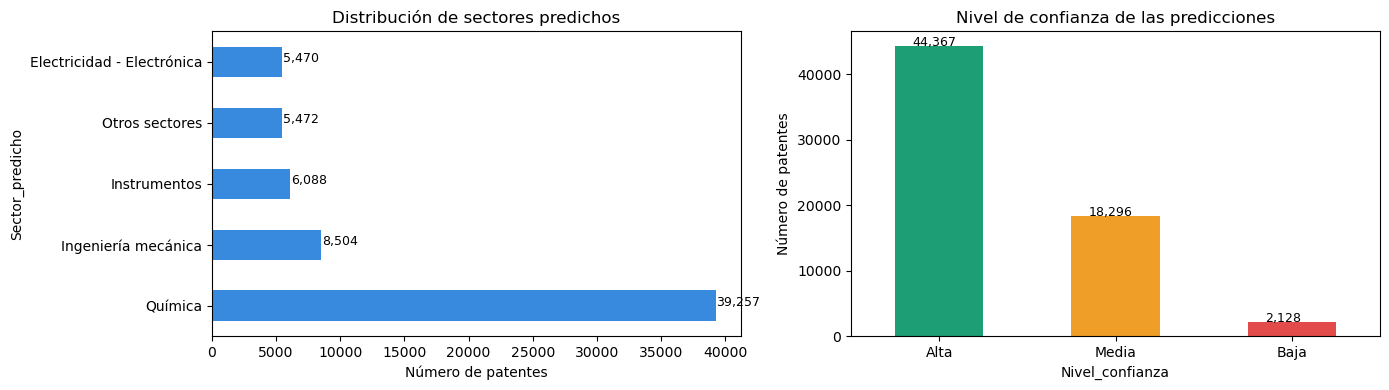


Resumen de confianza:
Nivel_confianza
Alta     44367
Media    18296
Baja      2128
Name: count, dtype: int64


In [19]:
# Distribución de predicciones
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_clasificable["Sector_predicho"].value_counts().plot(
    kind="barh", ax=axes[0], color="#378ADD")
axes[0].set_title("Distribución de sectores predichos")
axes[0].set_xlabel("Número de patentes")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_width()):,}", (p.get_width() + 50, p.get_y() + 0.25), fontsize=9)

df_clasificable["Nivel_confianza"].value_counts().plot(
    kind="bar", ax=axes[1],
    color=["#1D9E75", "#EF9F27", "#E24B4A"])
axes[1].set_title("Nivel de confianza de las predicciones")
axes[1].set_ylabel("Número de patentes")
axes[1].tick_params(axis="x", rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}", (p.get_x() + 0.1, p.get_height() + 50), fontsize=9)

plt.tight_layout()
plt.show()

print("\nResumen de confianza:")
print(df_clasificable["Nivel_confianza"].value_counts())


## 10. Exportar resultados

In [21]:
# Dataset completo con predicciones (incluye NaN donde no había IPC)
df_sin_ipc["Sector_predicho"]   = "Sin IPC - no clasificable"
df_sin_ipc["Confianza"]         = None
df_sin_ipc["Nivel_confianza"]   = "Sin IPC"

df_resultado = pd.concat([df_clasificable, df_sin_ipc], ignore_index=True)
df_resultado = df_resultado.drop(columns=["texto"])

# Guardar
df_resultado.to_csv("combined_dataset_clasificado.csv", index=False)
print(f"Archivo guardado: combined_dataset_clasificado.csv")
print(f"Shape final: {df_resultado.shape}")
df_resultado[["Application_Number", "IPC", "Sector_predicho",
              "Confianza", "Nivel_confianza"]].head(10)


Archivo guardado: combined_dataset_clasificado.csv
Shape final: (70465, 10)


,Application_Number,IPC,Sector_predicho,Confianza,Nivel_confianza
0,PCT/US2012/043526,B01J 27/14,Química,0.7680,Media
1,PCT/KR2012/004734,A61K 38/46; A61K 38/17; A61P 31/12,Química,0.9705,Alta
2,PCT/EP2012/061698,C09C 1/02; C01F 11/18,Química,0.8081,Alta
3,PCT/IB2012/001252,C07D 417/12; C07D 417/14; A61P 29/00; A61P 1/0...,Química,0.9740,Alta
4,PCT/US2012/043099,C07D 471/04; C07D 487/04; A61K 31/437; A61K 31...,Química,0.9960,Alta
5,PCT/IB2012/053170,A61K 8/02; A61K 8/04; A61K 8/44; A61K 8/73; A6...,Química,0.8917,Alta
6,PCT/US2012/042139,B67D 7/04,Ingeniería mecánica,0.8644,Alta
7,PCT/NZ2012/000104,A61K 31/366; A61K 31/429; A61P 33/00,Química,0.9492,Alta
8,PCT/KR2012/005521,H03K 17/693; H03K 19/173; G06F 3/00,Electricidad - Electrónica,0.7143,Media
9,PCT/IL2012/050215,E04C 2/54; E04D 3/28,Otros sectores,0.7418,Media
